# Cost of living

No true global gridded cost-of-living dataset exists (🔴 Tier C in `DATASETS.md`). We combine two sources on a compatible scale:

* **[Numbeo Cost of Living Index](https://www.numbeo.com/cost-of-living/rankings_current.jsp)** — ~555 cities, city-level index with USA/NYC baseline = 100. Scraped once and cached; higher = more expensive.
* **[World Bank Price Level Index (Households)](https://data.worldbank.org/indicator/PA.NUS.PRVT.PLI)** — country-level, ~200 countries, same 100=USA scale, latest year available per country. Used as a fallback for grid cells that have no Numbeo city within reach.

Because both series use the same USA=100 baseline, no rescaling is needed before blending.

The city layer is built with a `cKDTree` + exponential distance decay on Equal Earth (EPSG:8857) — same trick as `22_urbanity.ipynb`, but with a longer half-life (~210 km) because cost varies more smoothly across a region than "which cities are nearby". The country PLI is rasterized by Natural Earth 50m admin_0 polygons — same trick as `19_climate_vulnerability.ipynb`. City signal takes precedence wherever it exists; country PLI fills the remainder.

Finally we **sign-invert** to the atlas convention (higher = better = cheaper) and mask ocean via `is_land` from `grid.nc`.

In [1]:
import json
import re

import geopandas as gpd
import httpx
import numpy as np
import pandas as pd
import regionmask
import xarray as xr
from bs4 import BeautifulSoup
from scipy.spatial import cKDTree

from common import RAW_DIR, load_grid, plot_map, save_variable

VARIABLE = 'cost_of_living'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

# City-decay parameters. Longer than urbanity's 100 km because cost of living
# varies more smoothly across a metro region than "how big a city is nearby".
LAMBDA_M = 300_000       # 300 km e-folding (~210 km half-life)
CUTOFF_M = 800_000       # ignore cities beyond 800 km (contribution < exp(-8/3) ~ 0.07)
CHUNK    = 4_000

## 1. Fetch raw data

Three sources, all cached under `variable_raw/` on first run:

* **Numbeo cost-of-living rankings** (~285 KB HTML). One page, one HTTP GET with a browser User-Agent. If Numbeo starts 403/CAPTCHA-blocking, manually save the page HTML to `numbeo_rankings.html` and re-run.
* **World Bank PLI** — JSON from the WDI API (indicator `PA.NUS.PRVT.PLI`).
* **Natural Earth 10m populated places** and **50m admin_0 boundaries** — already cached by `22_urbanity.ipynb` and `19_climate_vulnerability.ipynb`; the guards below re-download only if missing.

In [2]:
NUMBEO_URL = 'https://www.numbeo.com/cost-of-living/rankings_current.jsp'
numbeo_html = variable_raw / 'numbeo_rankings.html'

if not numbeo_html.exists():
    print(f'fetching {NUMBEO_URL}')
    r = httpx.get(NUMBEO_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=60, follow_redirects=True)
    r.raise_for_status()
    numbeo_html.write_text(r.text)

WB_URL = ('https://api.worldbank.org/v2/country/all/indicator/PA.NUS.PRVT.PLI'
          '?format=json&per_page=20000&date=2010:2024')
wb_json_path = variable_raw / 'wb_pli.json'

if not wb_json_path.exists():
    print(f'fetching {WB_URL}')
    r = httpx.get(WB_URL, timeout=60)
    r.raise_for_status()
    wb_json_path.write_text(r.text)

# Reuse assets already cached by sibling notebooks.
ne_places_zip = RAW_DIR / 'urbanity' / 'ne_10m_populated_places.zip'
if not ne_places_zip.exists():
    NE_PLACES_URL = 'https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_populated_places.zip'
    print(f'downloading {NE_PLACES_URL}')
    from common import download
    await download(NE_PLACES_URL, ne_places_zip)

ne_countries_zip = RAW_DIR / 'climate_vulnerability' / 'ne_50m_admin_0_countries.zip'
if not ne_countries_zip.exists():
    NE_COUNTRIES_URL = 'https://naciscdn.org/naturalearth/50m/cultural/ne_50m_admin_0_countries.zip'
    print(f'downloading {NE_COUNTRIES_URL}')
    r = httpx.get(NE_COUNTRIES_URL, headers={'User-Agent': 'Mozilla/5.0'}, timeout=180, follow_redirects=True)
    r.raise_for_status()
    ne_countries_zip.parent.mkdir(parents=True, exist_ok=True)
    ne_countries_zip.write_bytes(r.content)

print(f'{numbeo_html.name}: {numbeo_html.stat().st_size / 1024:.0f} KB')
print(f'{wb_json_path.name}: {wb_json_path.stat().st_size / 1024:.0f} KB')

fetching https://www.numbeo.com/cost-of-living/rankings_current.jsp


fetching https://api.worldbank.org/v2/country/all/indicator/PA.NUS.PRVT.PLI?format=json&per_page=20000&date=2010:2024


numbeo_rankings.html: 279 KB
wb_pli.json: 1026 KB


## 2. Parse Numbeo cities

The Numbeo table lives under `<table id="t2">` and contains rows like `"Zurich, Switzerland"`, `"Fort Worth, TX, United States"`, or `"Lucknow (Lakhnau), India"`. Split on the last comma to isolate the country; take the first field as the city name. Cost of Living Index is column index 2 (0-based) — the Rank column in `<tbody>` is rendered by JS and comes back empty.

We keep both the raw city string (for debugging) and cleaned `(city, country)` for geocoding.

In [3]:
soup = BeautifulSoup(numbeo_html.read_text(), 'html.parser')
table = soup.find('table', id='t2')
assert table is not None, 'expected <table id="t2"> in Numbeo page'

rows = []
for tr in table.find('tbody').find_all('tr'):
    cols = [td.get_text(strip=True) for td in tr.find_all('td')]
    if len(cols) < 3:
        continue
    city_str = cols[1]
    try:
        cost = float(cols[2])
    except ValueError:
        continue
    parts = [p.strip() for p in city_str.split(',')]
    country = parts[-1]
    city = parts[0]
    rows.append({'city_raw': city_str, 'city': city, 'country': country, 'cost': cost})

numbeo = pd.DataFrame(rows)
print(f'{len(numbeo)} Numbeo cities parsed '
      f'(cost range {numbeo["cost"].min():.1f} – {numbeo["cost"].max():.1f})')
numbeo.head()

555 Numbeo cities parsed (cost range 17.5 – 125.3)


,city_raw,city,country,cost
0,"Zurich, Switzerland",Zurich,Switzerland,125.3
1,"George Town, Cayman Islands",George Town,Cayman Islands,118.3
2,"Basel, Switzerland",Basel,Switzerland,112.6
3,"Lugano, Switzerland",Lugano,Switzerland,112.1
4,"Geneva, Switzerland",Geneva,Switzerland,111.1


## 3. Geocode Numbeo cities against Natural Earth

Same cascading normaliser as `22_urbanity.ipynb`: strip parentheticals, lowercase, apply a small alias table for known name variants, fall back through `NAMEASCII` → `NAME` → `NAMEALT`. Numbeo helpfully gives us a country per city, which we use as a **disambiguator**: `(city, country)` matches beat unqualified name matches, so places like "Cambridge" resolve to the right country. If a city is unmatched (usually spelling variants or minor cities missing from Natural Earth's 7 300-entry set), we drop it and log the miss list — the country PLI layer catches the resulting grid gaps.

In [4]:
places = gpd.read_file(ne_places_zip)

ALIASES = {
    'bangalore':      'bengaluru',
    'calcutta':       'kolkata',
    'copenhagen':     'københavn',
    'antwerp':        'antwerpen',
    'gothenburg':     'göteborg',
    'ulan bator':     'ulaanbaatar',
    'macao':          'macau',
    'limassol':       'lemesos',
    'port of spain':  'port-of-spain',
    'washington dc':  'washington, d.c.',
    'washington':     'washington, d.c.',
    'the hague':      "'s-gravenhage",
    'nur-sultan':     'astana',
    'brussels':       'brussels',
}

def normalize_name(name):
    n = (name or '').strip().lower().replace('’', "'")
    n = re.sub(r'\s*\(.*?\)\s*', '', n).strip()
    return ALIASES.get(n, n)

def normalize_country(name):
    return (name or '').strip().lower()

# Build both a country-scoped and an unscoped lookup keyed on cleaned names.
# Country-scoped wins when available; the unscoped map is the fallback and
# always keeps the highest-population candidate on collisions.
scoped, unscoped = {}, {}
def register(idx, name, country_name):
    key = normalize_name(name)
    if not key:
        return
    pop = places.at[idx, 'POP_MAX']
    ckey = normalize_country(country_name)
    if ckey:
        prev = scoped.get((ckey, key))
        if prev is None or pop > places.at[prev, 'POP_MAX']:
            scoped[(ckey, key)] = idx
    prev = unscoped.get(key)
    if prev is None or pop > places.at[prev, 'POP_MAX']:
        unscoped[key] = idx

for i in range(len(places)):
    country = places.at[i, 'ADM0NAME']
    register(i, places.at[i, 'NAMEASCII'], country)
    register(i, places.at[i, 'NAME'], country)

for i in range(len(places)):
    alt = places.at[i, 'NAMEALT']
    if isinstance(alt, str):
        country = places.at[i, 'ADM0NAME']
        for name in alt.split('|'):
            key = normalize_name(name)
            if key and (normalize_country(country), key) not in scoped:
                register(i, name, country)

matched_idx = []
unmatched = []
for _, row in numbeo.iterrows():
    city_key = normalize_name(row['city'])
    ckey = normalize_country(row['country'])
    idx = scoped.get((ckey, city_key)) or unscoped.get(city_key)
    if idx is None:
        unmatched.append(row['city_raw'])
        matched_idx.append(np.nan)
    else:
        matched_idx.append(idx)

numbeo['ne_idx'] = matched_idx
matched = numbeo.dropna(subset=['ne_idx']).copy()
matched['ne_idx'] = matched['ne_idx'].astype(int)
matched['lat'] = places.loc[matched['ne_idx'], 'LATITUDE'].values
matched['lon'] = places.loc[matched['ne_idx'], 'LONGITUDE'].values

print(f'geocoded {len(matched)}/{len(numbeo)} Numbeo cities '
      f'({100 * len(matched) / len(numbeo):.1f}%)')
print(f'unmatched ({len(unmatched)}): {unmatched}')

geocoded 503/555 Numbeo cities (90.6%)
unmatched (52): ['St. Gallen, Switzerland', 'Lucerne, Switzerland', 'Saint Helier, Jersey', 'Jersey City, NJ, United States', 'Guildford, United Kingdom', 'Espoo, Finland', 'Saint Louis, MO, United States', 'Delft, Netherlands', 'Darmstadt, Germany', 'Leiden, Netherlands', 'Almere, Netherlands', 'Brescia, Italy', 'Freiburg im Breisgau, Germany', 'Milton Keynes, United Kingdom', 'Burnaby, Canada', 'Guelph, Canada', 'Erlangen, Germany', 'Aachen, Germany', 'Surrey, Canada', 'Lund, Sweden', 'Sliema, Malta', 'Padova, Italy', 'Villach, Austria', 'Leuven, Belgium', 'Mississauga, Canada', "Reggio Nell'emilia, Italy", 'College Station, TX, United States', 'Remagen, Germany', 'Rimini, Italy', 'Brampton, Canada', 'Quebec City, Canada', 'Heraklion, Greece', 'Ras al-Khaimah, United Arab Emirates', 'San Miguel de Allende, Mexico', 'Larnaca, Cyprus', 'Las Palmas de Gran Canaria, Spain', 'New Taipei City, Taiwan', 'Budva, Montenegro', 'Patras, Greece', 'Al Khobar

## 4. Country-level PLI fallback layer

Take the most-recent non-null value per country from the World Bank JSON, join to Natural Earth 50m admin_0 polygons by ISO3, and rasterize onto the atlas grid via `regionmask` — same pattern as `19_climate_vulnerability.ipynb`. Values are already on the USA=100 scale, so no rescaling.

In [5]:
grid = load_grid()

wb_payload = json.loads(wb_json_path.read_text())
wb_rows = wb_payload[1]

latest = {}
for row in wb_rows:
    iso3 = row.get('countryiso3code')
    val = row.get('value')
    if val is None or not iso3:
        continue
    year = int(row['date'])
    prev = latest.get(iso3)
    if prev is None or year > prev[0]:
        latest[iso3] = (year, val)

country_pli = pd.Series({iso: v for iso, (_, v) in latest.items()}, name='pli')
print(f'{len(country_pli)} countries with a PLI value '
      f'(range {country_pli.min():.1f} – {country_pli.max():.1f})')

countries = (
    gpd.read_file(f'zip://{ne_countries_zip}')
    .to_crs('EPSG:4326')
    [['ISO_A3_EH', 'NAME', 'geometry']]
    .rename(columns={'ISO_A3_EH': 'ISO3'})
)
usable = countries.merge(country_pli, left_on='ISO3', right_index=True).reset_index(drop=True)
print(f'{len(usable)} of {len(countries)} country polygons joined to a PLI value')

regions = regionmask.from_geopandas(usable, overlap=False)
region_idx = regions.mask(grid.lon, grid.lat)

idx = region_idx.values
valid = ~np.isnan(idx)
lookup = usable['pli'].to_numpy(dtype='float32')
country_layer = xr.DataArray(
    np.where(valid, lookup[np.where(valid, idx, 0).astype(int)], np.nan).astype('float32'),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name='pli_country',
)
print(f'country layer: {int(country_layer.notnull().sum())} covered cells')

208 countries with a PLI value (range 17.5 – 144.1)
209 of 242 country polygons joined to a PLI value


country layer: 61326 covered cells


## 5. City-decay layer via KDTree

Project Numbeo cities and grid cell centres to Equal Earth (EPSG:8857) so distances are planar metres. Query all cities within `CUTOFF_M` around each cell, then compute a distance-weighted **mean** cost (not sum — we want a value on the Numbeo/PLI scale, not an accumulated total):

    cost(cell) = Σ(cost_i · w_i) / Σ(w_i),   w_i = exp(-d_i / LAMBDA_M)

Cells with zero neighbours stay NaN and will be filled from the country layer.

In [6]:
city_pts = gpd.GeoSeries(
    gpd.points_from_xy(matched['lon'].values, matched['lat'].values),
    crs='EPSG:4326',
).to_crs('EPSG:8857')
city_xy = np.column_stack([city_pts.x.values, city_pts.y.values])
cost = matched['cost'].values.astype(np.float64)
tree = cKDTree(city_xy)

lat2d, lon2d = np.meshgrid(grid.lat.values, grid.lon.values, indexing='ij')
cell_pts = gpd.GeoSeries(
    gpd.points_from_xy(lon2d.ravel(), lat2d.ravel()),
    crs='EPSG:4326',
).to_crs('EPSG:8857')
cell_xy = np.column_stack([cell_pts.x.values, cell_pts.y.values])

city_cost_flat = np.full(cell_xy.shape[0], np.nan, dtype=np.float64)
for start in range(0, cell_xy.shape[0], CHUNK):
    stop = min(start + CHUNK, cell_xy.shape[0])
    neighbours = tree.query_ball_point(cell_xy[start:stop], r=CUTOFF_M)
    for offset, idxs in enumerate(neighbours):
        if not idxs:
            continue
        idxs = np.asarray(idxs)
        d = np.linalg.norm(cell_xy[start + offset] - city_xy[idxs], axis=1)
        w = np.exp(-d / LAMBDA_M)
        city_cost_flat[start + offset] = (cost[idxs] * w).sum() / w.sum()

city_layer = xr.DataArray(
    city_cost_flat.reshape(lat2d.shape).astype(np.float32),
    coords={'lat': grid.lat, 'lon': grid.lon},
    dims=('lat', 'lon'),
    name='cost_city_layer',
)
print(f'city layer: {int(city_layer.notnull().sum())} covered cells '
      f'(range {float(city_layer.min()):.1f} – {float(city_layer.max()):.1f})')

city layer: 65878 covered cells (range 17.9 – 108.4)


## 6. Blend, sign-invert, mask ocean

City signal wins wherever it exists; country PLI fills the rest. Both scales already share USA=100, so a straight `fillna` produces a coherent map. We then sign-invert (negate) so higher = cheaper = better for livability, matching the atlas convention used by `weighted_score` in `90_scoring.ipynb`. Ocean is masked via `is_land` from `grid.nc`.

In [7]:
blended = city_layer.fillna(country_layer)

values = (
    (-blended)
    .astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['units'] = 'negated price-level index (USA=−100; higher = cheaper = better)'
values.attrs['source'] = (
    'Numbeo Cost of Living Index (rankings_current.jsp) blended with World Bank '
    'PA.NUS.PRVT.PLI (Price Level Index, Households) country fallback'
)
values.attrs['orientation'] = 'higher = cheaper (already inverted for atlas)'

land_cells = int((grid.is_land == 1).sum())
covered = int(values.notnull().sum())
print(f'{covered}/{land_cells} land cells covered ({100 * covered / land_cells:.1f}%)')
print(f'values range: {float(values.min()):.1f} .. {float(values.max()):.1f}')

61179/85959 land cells covered (71.2%)
values range: -115.1 .. -18.0


## 7. Plot

<Axes: title={'center': 'Cost of living (inverted — higher = cheaper)'}, xlabel='longitude', ylabel='latitude'>

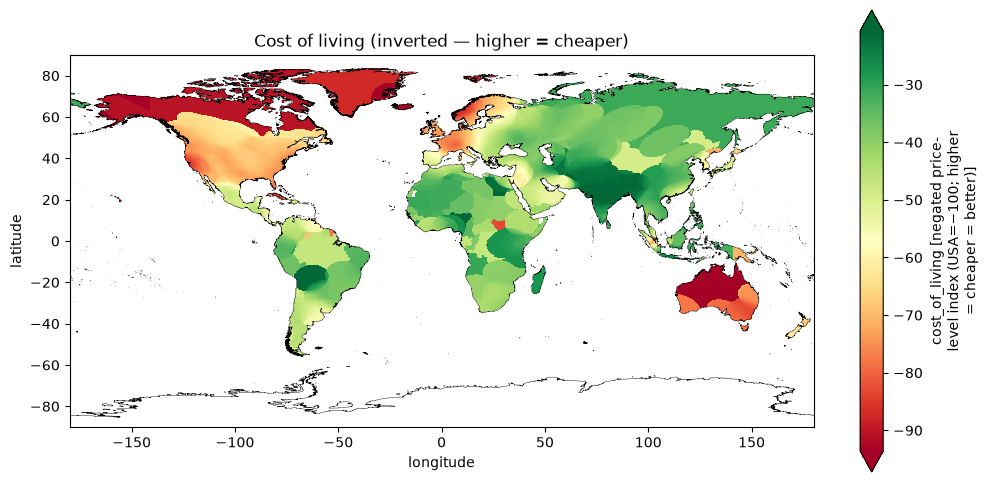

In [8]:
plot_map(values, cmap='RdYlGn', robust=True, title='Cost of living (inverted — higher = cheaper)')

## 8. Save

In [9]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/cost_of_living.nc
